# Regresión de la calidad de vinos

## Exploración de datos

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("willianoliveiragibin/modeling-wine")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_file_path = os.path.join(path, csv_files[0])

wine_df = pd.read_csv(csv_file_path)

wine_df.head()

c:\todo\Anaconda\envs\curso_ia\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6,"R$ 45.512,00"
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6,"R$ 45.421,00"
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6,"R$ 45.301,00"
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"


Transformo el alcohol a un valor en %.

In [5]:
wine_df['alcohol'] = (wine_df['alcohol']
                .str.replace('R\$ ', '', regex=True)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.', regex=False)
                .astype(float)/1000.0)

wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6,45.512
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6,45.421
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6,45.301
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,45.544
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,45.544


In [6]:
# Search for missing values
missing_values = wine_df.isnull().sum()

print("Missing values in each column:")
if missing_values.sum() == 0: 
    print("No missing values found!")
else:
    print(missing_values)

Missing values in each column:
No missing values found!


In [7]:
# Print every column name and its data type
print("\nColumn names and data types:")
for column in wine_df.columns:
    print(f"{column}: {wine_df[column].dtype}")


Column names and data types:
fixed acidity: float64
volatile acidity: float64
citric acid: float64
residual sugar: float64
chlorides: float64
free sulfur dioxide: float64
total sulfur dioxide: float64
density: float64
pH: float64
sulphates: float64
quality: int64
alcohol: float64


Sospecho que los valores relacionados con ácidos van a ser un poco redundantes. Veamos la correlación entre las variables:

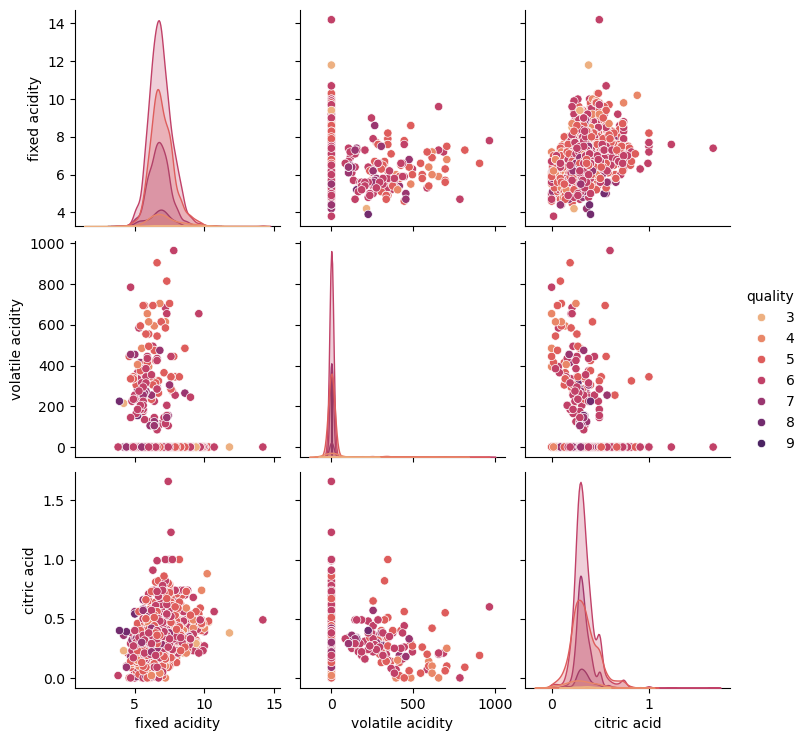

In [8]:
# Acid data
acid_df = wine_df[["fixed acidity", "volatile acidity", "citric acid", "quality"]]

# Create a pairplot to visualize relationships between features
sns.pairplot(acid_df, hue="quality", palette="flare")


Las variables "fixed acidity" y "citric acidity" parecen estar ligeramente correlacionadas, pero no lo suficiente como para considerar eliminar ninguna de ellas.

## Preparación de los datos
Voy a normalizar los datos para prepararlos para el entrenamiento. También los separaré en 90-10 para entrenamiento y test. Para validar mi entrenamiento usaré un K-fold de 5 grupos.

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(wine_df, test_size=0.1, random_state=42)
train_df.shape, test_df.shape

((4408, 12), (490, 12))

In [10]:
# Separo la variable objetivo (quality) de las características
X_train = train_df.drop("quality", axis=1)
y_train = train_df["quality"]

X_test = test_df.drop("quality", axis=1)
y_test = test_df["quality"]

In [11]:
# Normalizo las características utilizando StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
import tensorflow as tf

# Define a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

c:\todo\Anaconda\envs\curso_ia\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 12.3962 - mae: 2.9301 - val_loss: 3.5231 - val_mae: 1.5233
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8521 - mae: 1.3004 - val_loss: 2.1888 - val_mae: 1.1598
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9469 - mae: 1.0734 - val_loss: 1.6324 - val_mae: 0.9969
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4548 - mae: 0.9290 - val_loss: 1.2497 - val_mae: 0.8704
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1428 - mae: 0.8222 - val_loss: 1.0399 - val_mae: 0.7960
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9590 - mae: 0.7595 - val_loss: 0.9048 - val_mae: 0.7443
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8332 - mae: 0.7094 - val_loss: 0.8076 - val_mae: 0.7019
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7550 - mae: 0.6755 - val_loss: 0.7612 - val_mae: 0.6779
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

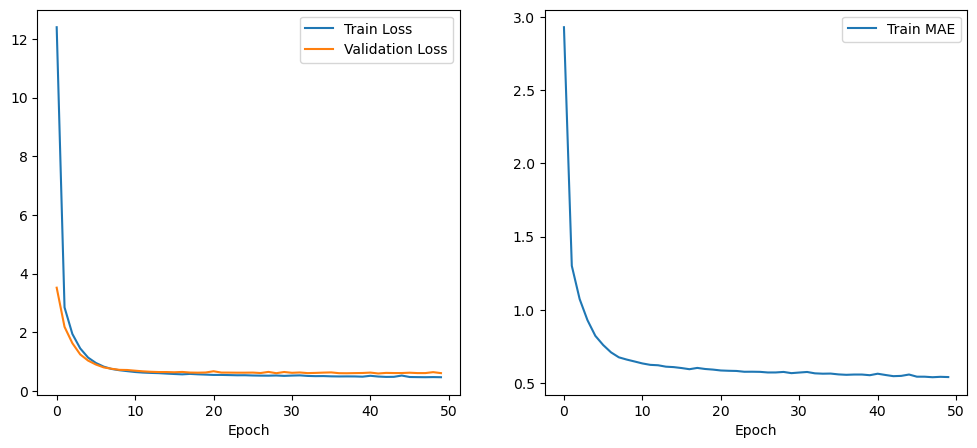

In [14]:
# Visualizo las curvas de entrenamiento y validación
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.xlabel('Epoch')
plt.legend()
plt.show()  